<a href="https://colab.research.google.com/github/nando135/textclassification/blob/main/fernando_textclassification_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install nltk
!pip install pandas
!pip install optuna
!pip install scikeras



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.6/386.6 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.9/231.9 kB 15.9 MB/s eta 0:00:00


In [42]:
import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.corpus import wordnet
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk import pos_tag
import optuna
import tensorflow as tf
from tensorflow import keras
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd
from collections import Counter
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import RandomizedSearchCV
import random
from sklearn.metrics import accuracy_score

# Download necessary NLTK data files
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')



[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

In [43]:
def load_dataset(path, sep='\t', column_names=["text", "label"]):

    try:
        df = pd.read_csv(path, sep=sep, names=column_names)
        print(f"Data loaded successfully from {path}")
        return df
    except Exception as e:
        print(f"Error loading data from {path}: {e}")
        return None



In [44]:
def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

def preprocess_nltk_text(text):
    en_stopwords = set(stopwords.words('english'))
    lemmatizer = WordNetLemmatizer()
    words = word_tokenize(str(text))
    filtered_words = [word for word in words if word.isalpha() and word.lower() not in en_stopwords]
    pos_tags = pos_tag(filtered_words)
    lemmas = []
    for word, tag in pos_tags:
        wordnet_pos = get_wordnet_pos(tag)
        lemma = lemmatizer.lemmatize(word.lower(), wordnet_pos)
        lemmas.append(lemma)

    return " ".join(lemmas)



In [45]:
def drop_label_rows(df, label_column='label', label_to_drop='neutral'):
    filtered_df = df[df[label_column] != label_to_drop].reset_index(drop=True)
    print(f"Dropped rows with label '{label_to_drop}'. Remaining rows: {len(filtered_df)}")
    filtered_df = filtered_df.dropna()
    label_encoder = LabelEncoder()
    filtered_df[label_column] = label_encoder.fit_transform(filtered_df[label_column])

    return filtered_df
def print_head(df, n=5):
    print(df.head(n))

def add_clean_column(df, text_column='text', new_column='clean_text'):

    df[new_column] = df[text_column].apply(preprocess_nltk_text)
    return df


In [46]:
def vectorize_text(df, text_column='clean_text', label_column='label', max_features=500):

    vectorizer = TfidfVectorizer(max_features=max_features)
    X = vectorizer.fit_transform(df[text_column])
    y = df[label_column]

    return X, y, max_features


In [47]:
def count_sentiment_distribution(df, label_column='label'):
    counts = df[label_column].value_counts()
    print("Label Distribution:\n")
    print(counts)

    # Optional: Print only positive and negative counts
    print("\nPositive count:", counts.get('positive', 0))
    print("Negative count:", counts.get('negative', 0))


In [48]:
def auto_resample_data(X, y, random_state=42):

    original_dist = Counter(y)
    print("Original class distribution:", original_dist)
    majority_class = max(original_dist, key=original_dist.get)
    minority_class = min(original_dist, key=original_dist.get)

    maj_count = original_dist[majority_class]
    min_count = original_dist[minority_class]
    ratio = maj_count / min_count
    if ratio > 2.0:
        sampler = RandomUnderSampler(random_state=random_state)
        method = 'undersampling'
    elif 1.5 < ratio <= 2.0:
        sampler = SMOTE(random_state=random_state)
        method = 'smote'
    else:
        sampler = RandomOverSampler(random_state=random_state)
        method = 'oversampling'

    print(f"Applying {method.upper()}...")

    X_resampled, y_resampled = sampler.fit_resample(X, y)
    print("Resampled class distribution:", Counter(y_resampled))

    return X_resampled, y_resampled


In [49]:
def split_train_test(X, y, test_size=0.2, random_state=42):

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    print(f"Training set size: {X_train.shape} samples")
    print(f"Testing set size: {X_test.shape} samples")

    return X_train, X_test, y_train, y_test

In [50]:
def build_model(input_dim=500, learning_rate=1e-3):

    dnn_model = Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])

    dnn_model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return dnn_model


In [51]:
def manual_random_search_dnn(X_train, y_train, X_test, y_test,
                              input_dim=500, n_iter=10,
                              epochs_list=[10, 20, 25],
                              batch_sizes=[16, 32, 64]):


    best_model = None
    best_score = 0
    best_params = {}

    for i in range(n_iter):
        # Randomly sample parameters
        epochs = random.choice(epochs_list)
        batch_size = random.choice(batch_sizes)

        print(f"\n▶️ Trial {i+1} | epochs={epochs}, batch_size={batch_size}")

        model = build_model(input_dim=input_dim)
        model.fit(
            X_train.toarray(), y_train,
            epochs=epochs,
            batch_size=batch_size,
            verbose=0,
            validation_split=0.2
        )

        preds = model.predict(X_test.toarray())
        preds = (preds > 0.5).astype(int).flatten()
        score = accuracy_score(y_test, preds)

        print(f"🧪 Accuracy: {score:.4f}")

        if score > best_score:
            best_model = model
            best_score = score
            best_params = {'epochs': epochs, 'batch_size': batch_size}

    print("\n✅ Best Parameters Found:", best_params)
    print(f"✅ Best Accuracy: {best_score:.4f}")

    return best_model, best_score, best_params



In [52]:
df = load_dataset("/content/sample_data/train_preprocess.tsv", sep='\t')
df = drop_label_rows(df, label_column='label', label_to_drop='neutral')


Data loaded successfully from /content/sample_data/train_preprocess.tsv
Dropped rows with label 'neutral'. Remaining rows: 9852


In [53]:
df = add_clean_column(df, text_column='text', new_column='clean_text')

In [54]:
count_sentiment_distribution(df)


Label Distribution:

label
1    6416
0    3436
Name: count, dtype: int64

Positive count: 0
Negative count: 0


In [55]:
X, y, input_dim = vectorize_text(df, text_column='clean_text', label_column='label', max_features=500)

In [56]:
X_resampled, y_resampled = auto_resample_data(X, y)

Original class distribution: Counter({1: 6416, 0: 3436})
Applying SMOTE...
Resampled class distribution: Counter({1: 6416, 0: 6416})


In [57]:
X_train, X_test, y_train, y_test = split_train_test(X_resampled, y_resampled)

Training set size: (10265, 500) samples
Testing set size: (2567, 500) samples


In [58]:
model = build_model(input_dim=X_train.shape[1], learning_rate=1e-3)
history = model.fit(
    X_train.toarray(),
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)
test_loss, test_acc = model.evaluate(X_test.toarray(), y_test)
print(f"\nBaseline Test Accuracy: {test_acc:.4f}")

Epoch 1/20
257/257 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7928 - loss: 0.5270 - val_accuracy: 0.8928 - val_loss: 0.2805
Epoch 2/20
257/257 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9040 - loss: 0.2544 - val_accuracy: 0.9006 - val_loss: 0.2575
Epoch 3/20
257/257 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9147 - loss: 0.2246 - val_accuracy: 0.9016 - val_loss: 0.2519
Epoch 4/20
257/257 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9174 - loss: 0.2145 - val_accuracy: 0.8982 - val_loss: 0.2509
Epoch 5/20
257/257 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9240 - loss: 0.1969 - val_accuracy: 0.9001 - val_loss: 0.2538
Epoch 6/20
257/257 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9262 - loss: 0.1903 - val_accuracy: 0.9016 - val_loss: 0.2499
Epoch 7/20
257/257 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9299 - loss: 0.1917 - val_accuracy: 0.9006 - val_loss: 0.2532
Epoch 8/20
257/257 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9289 - loss: 0.1841 - val_accuracy: 0.

In [59]:
best_model, best_score, best_params = manual_random_search_dnn(
    X_train, y_train, X_test, y_test,
    input_dim=X_train.shape[1]
)

print("\n🎯 Best Model Found")
print("Best Parameters:", best_params)
print("Best Accuracy:", round(best_score, 4))


▶️ Trial 1 | epochs=25, batch_size=32
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
🧪 Accuracy: 0.9061

▶️ Trial 2 | epochs=10, batch_size=64
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
🧪 Accuracy: 0.8983

▶️ Trial 3 | epochs=25, batch_size=64
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
🧪 Accuracy: 0.8999

▶️ Trial 4 | epochs=10, batch_size=16
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
🧪 Accuracy: 0.9026

▶️ Trial 5 | epochs=10, batch_size=32
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
🧪 Accuracy: 0.8983

▶️ Trial 6 | epochs=10, batch_size=32
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
🧪 Accuracy: 0.8983

▶️ Trial 7 | epochs=20, batch_size=64
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
🧪 Accuracy: 0.8987

▶️ Trial 8 | epochs=20, batch_size=32
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
🧪 Accuracy: 0.9011

▶️ Trial 9 | epochs=20, batch_size=32
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
🧪 Accuracy: 0.9034

▶️ Trial 10 | epochs=20, batch_size=32
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
🧪 Accuracy: 0.9057

✅ Best Parameters Found: {'e

In [60]:
retrained_model = build_model(input_dim=X_train.shape[1])

history = retrained_model.fit(
    X_train.toarray(),
    y_train,
    epochs=best_params['epochs'],
    batch_size=best_params['batch_size'],
    validation_split=0.2,
    verbose=1
)


final_loss, final_acc = retrained_model.evaluate(X_test.toarray(), y_test)
print(f"\n✅ Final Test Accuracy After Retraining: {final_acc:.4f}")

Epoch 1/25
257/257 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8247 - loss: 0.5199 - val_accuracy: 0.8977 - val_loss: 0.2784
Epoch 2/25
257/257 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9049 - loss: 0.2496 - val_accuracy: 0.9026 - val_loss: 0.2587
Epoch 3/25
257/257 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9187 - loss: 0.2196 - val_accuracy: 0.9016 - val_loss: 0.2502
Epoch 4/25
257/257 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9280 - loss: 0.2025 - val_accuracy: 0.9031 - val_loss: 0.2491
Epoch 5/25
257/257 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9273 - loss: 0.1906 - val_accuracy: 0.8987 - val_loss: 0.2499
Epoch 6/25
257/257 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9300 - loss: 0.1861 - val_accuracy: 0.9031 - val_loss: 0.2486
Epoch 7/25
257/257 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9263 - loss: 0.1861 - val_accuracy: 0.9040 - val_loss: 0.2477
Epoch 8/25
257/257 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9324 - loss: 0.1758 - val_accuracy: 0.

In [62]:
from sklearn.metrics import classification_report

y_pred_probs = retrained_model.predict(X_test.toarray())
y_pred = (y_pred_probs > 0.5).astype(int).flatten()


print("\n📄 Classification Report:")
print(classification_report(y_test, y_pred, digits=4))


81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

📄 Classification Report:
              precision    recall  f1-score   support

           0     0.8844    0.9307    0.9070      1299
           1     0.9250    0.8754    0.8995      1268

    accuracy                         0.9034      2567
   macro avg     0.9047    0.9031    0.9032      2567
weighted avg     0.9045    0.9034    0.9033      2567



81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


<ipython-input-63-a815942ee94b>:18: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


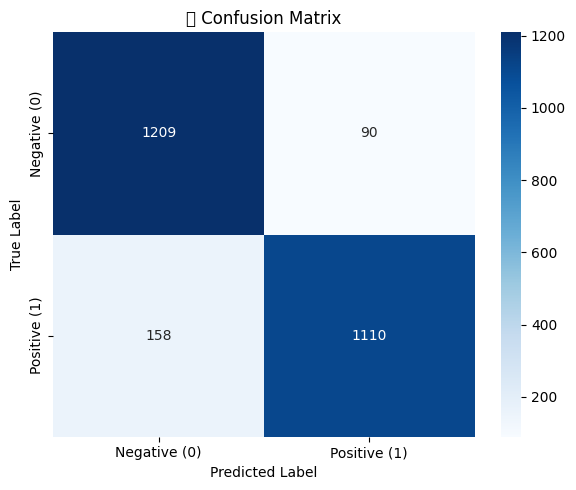

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

y_pred_probs = retrained_model.predict(X_test.toarray())
y_pred = (y_pred_probs > 0.5).astype(int).flatten()


cm = confusion_matrix(y_test, y_pred)
labels = ['Negative (0)', 'Positive (1)']
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)

plt.title("🔍 Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()